In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load

df = pd.read_csv("data/weather.csv", parse_dates = ["time"])
df.head()

,time,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,snowfall,weather_code,cloud_cover,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,shortwave_radiation,vapour_pressure_deficit,soil_temperature_0_to_7cm
0,2000-01-01 00:00:00,-4.5,75,-8.3,0.2,0.0,0.14,71,96,1004.9,880.6,1.8,323,0.0,0.11,-2.1
1,2000-01-01 01:00:00,-4.5,76,-8.1,0.1,0.0,0.07,71,94,1004.8,880.6,3.3,319,0.0,0.11,-2.1
2,2000-01-01 02:00:00,-4.6,77,-8.0,0.0,0.0,0.07,71,98,1004.4,880.2,4.3,318,0.0,0.10,-2.1
3,2000-01-01 03:00:00,-4.7,76,-8.3,0.0,0.0,0.07,71,93,1004.0,879.8,4.1,315,0.0,0.11,-2.2
4,2000-01-01 04:00:00,-6.9,75,-10.6,0.0,0.0,0.07,71,97,1004.7,879.4,3.8,311,0.0,0.09,-3.6


In [3]:
# Inspect
# UPDATE: From Filter to Inspect

# Structure
print(df.shape, "\n")
print(df.dtypes, "\n")

# Missingness
print(df.isnull().sum(), "\n")

# Duplicates
print("Rows:", df[df.duplicated(keep = False)], "\n")
print("Times:", df[df["time"].duplicated(keep = False)], "\n")

# Sanity
print(df["time"].min(), "to", df["time"].max(), "\n")
print(df["time"].diff().value_counts(), "\n")
print(df.describe().T)

(233016, 16) 

time                         datetime64[us]
temperature_2m                      float64
relative_humidity_2m                  int64
dew_point_2m                        float64
precipitation                       float64
rain                                float64
snowfall                            float64
weather_code                          int64
cloud_cover                           int64
pressure_msl                        float64
surface_pressure                    float64
wind_speed_10m                      float64
wind_direction_10m                    int64
shortwave_radiation                 float64
vapour_pressure_deficit             float64
soil_temperature_0_to_7cm           float64
dtype: object 

time                         0
temperature_2m               0
relative_humidity_2m         0
dew_point_2m                 0
precipitation                0
rain                         0
snowfall                     0
weather_code                 0
cloud_cover      

In [4]:
# Clean
# No cleaning required after inspection.
# UPDATE: Added section

In [5]:
# Transform

time_df = (
    df.loc[(df["time"].dt.year.between(2024, 2026)) &
           (df["time"].dt.month.eq(4)),
           ["time", "temperature_2m"]]
      .assign(time = lambda x: x["time"].dt.year)
      .rename(columns = {"time":"year", "temperature_2m":"temperature"})
)

output_df = time_df.groupby("year").max().round(2)
output_df

,temperature
year,
2024,17.6
2025,20.7
2026,23.5


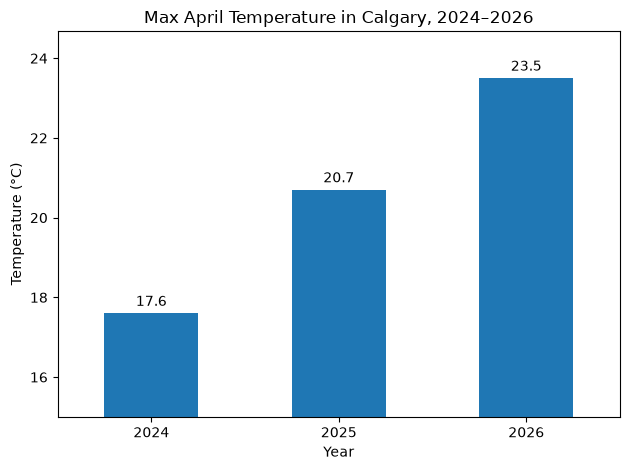

In [6]:
# Visualize - Pasted

ax = output_df.plot(y = "temperature", kind = "bar", legend = False)

ax.set_title("Max April Temperature in Calgary, 2024–2026")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")

# Start y-axis at 15
ax.set_ylim(bottom = 15)

# Value labels above bars
ax.bar_label(ax.containers[0], fmt = "%.1f", padding = 3)

# Keep year labels horizontal
ax.tick_params(axis = "x", rotation = 0)

plt.tight_layout()
plt.savefig("outputs/max_april_temp.png", dpi = 150, bbox_inches = "tight")
plt.show()